In [1]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, INTERIM_DIR, FIGURES_DIR
from pathlib import Path

import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

from cmap import Colormap
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]

cm = Colormap("colorbrewer:Set2")
norm = TwoSlopeNorm(vmin=-25, vcenter=0, vmax=25)
dashed_style = (0, (5, 5))

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "axes.grid":         False,
    "figure.constrained_layout.use": True,
})

def plot_heatmaps(mats, times, titles, norm=None, cmap="hot", figsize=None):
    """Plot [T, N] matrices as side-by-side heatmaps."""
    n = len(mats)

    if figsize is None:
        figsize = (4 * n, 4)

    fig, axes = plt.subplots(
        1, n, figsize=figsize, sharey=True, squeeze=False
    )
    axes = axes.ravel()

    for ax, mat, time, title in zip(axes, mats, times, titles):
        im = ax.imshow(
            mat.T,
            aspect="auto",
            origin="lower",
            extent=[time[0], time[-1], 0, mat.shape[1]],
            cmap=cmap,
            norm=norm,
        )

        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    return fig, axes

def time_index(t, target):
    return np.argmin(np.abs(t - target))

def amplitude_at_threshold(sta, t, threshold):
    before_idx = time_index(t, -threshold)
    after_idx = time_index(t, threshold)
    return sta[after_idx, :] - sta[before_idx, :]

def plot_scatter_with_regression(ax, x, y, title=None, xlabel=None, ylabel=None, line_color='tab:red', scatter_color='k'):
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = fit.intercept + fit.slope * x_fit

    ax.scatter(x, y, s=15, c=scatter_color, alpha=0.8)
    ax.plot(x_fit, y_fit, color=line_color, linewidth=0.7, linestyle='--')
    ax.axhline(0, color='0.5', linestyle='--', linewidth=1)
    ax.axvline(0, color='0.5', linestyle='--', linewidth=1)

    label = (
        f'R = {fit.rvalue:.2f}\n'
        f'p = {fit.pvalue:.2g}\n'
    )

    ax.text(0.05, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=18)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=18)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=18)

In [26]:
tsi = []
sta_nrem = []

for mouse_id in MOUSE_IDS:
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")  
    sta_nrem.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_nrem_upstate.npz"))

    tsi.append(turn_units['turn_index'])
        
tsi = np.concatenate(tsi)
order = np.argsort(tsi)
tsi = tsi[order]

sta_nrem = np.rad2deg(np.column_stack(sta_nrem))[:, order]
sta_original = nap.load_file(PROCESSED_DIR / "dual" / "sta_awake_sorted.npz")
print(sta_original.shape)
nanmask = np.any(np.isnan(sta_nrem), axis=0)
print(sta_original.d[:, nanmask])
tsi = tsi[~nanmask]
zero_cross = np.argmin(np.abs(tsi)).item()

sta_original = sta_original[:, ~nanmask]
sta_nrem = sta_nrem[:, ~nanmask]

(81, 79)
[[-3.19266324]
 [-3.11573549]
 [-3.06416263]
 [-3.02955219]
 [-2.96570655]
 [-2.87157226]
 [-2.79530334]
 [-2.68808241]
 [-2.62456862]
 [-2.58238924]
 [-2.49123427]
 [-2.44913663]
 [-2.34008503]
 [-2.29566539]
 [-2.18886652]
 [-2.08878022]
 [-2.03455848]
 [-1.96481249]
 [-1.88970028]
 [-1.9085267 ]
 [-1.85075485]
 [-1.78189003]
 [-1.79607282]
 [-1.75693119]
 [-1.73091076]
 [-1.71998588]
 [-1.64629061]
 [-1.51970101]
 [-1.3724063 ]
 [-1.29468165]
 [-1.24924648]
 [-1.19702697]
 [-1.1233571 ]
 [-1.06906827]
 [-0.95688859]
 [-0.77893026]
 [-0.59598877]
 [-0.4227876 ]
 [-0.29470893]
 [-0.14459481]
 [ 0.        ]
 [ 0.1215757 ]
 [ 0.29190386]
 [ 0.43839333]
 [ 0.58679881]
 [ 0.64849531]
 [ 0.67942675]
 [ 0.69762917]
 [ 0.71761382]
 [ 0.73596476]
 [ 0.7649058 ]
 [ 0.79914376]
 [ 0.80846085]
 [ 0.82893781]
 [ 0.81349894]
 [ 0.80224901]
 [ 0.82537627]
 [ 0.87230224]
 [ 0.86748809]
 [ 0.84126079]
 [ 0.8069885 ]
 [ 0.76413577]
 [ 0.71087893]
 [ 0.67612632]
 [ 0.66141989]
 [ 0.67257982]
 

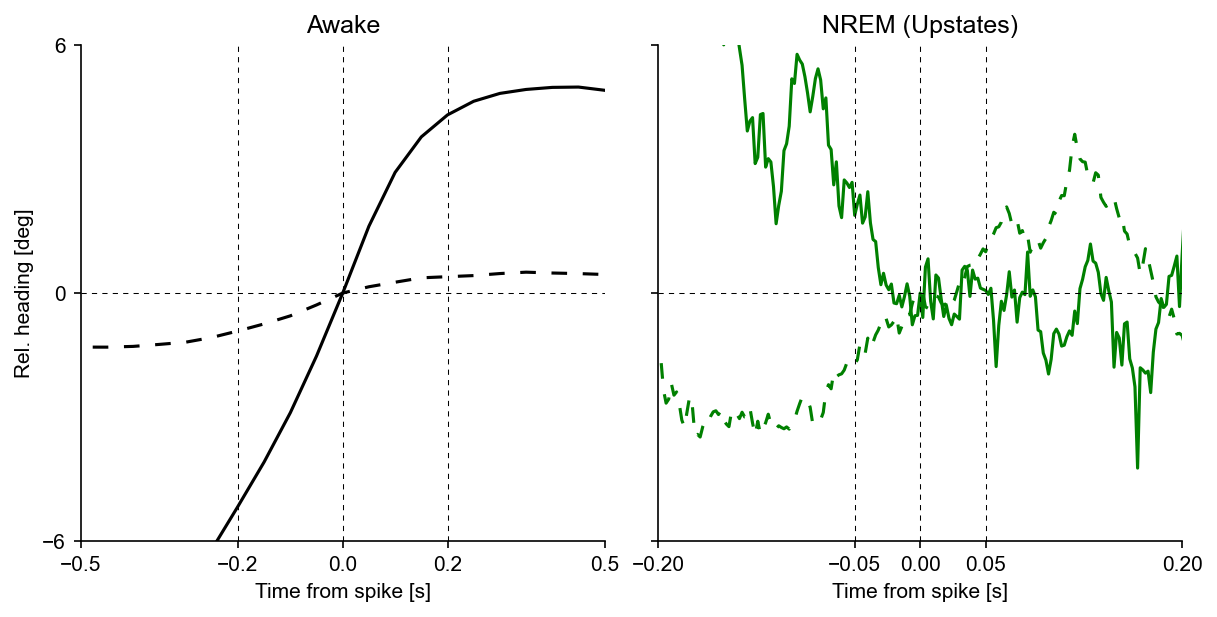

In [58]:
f, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

axes[0].plot(sta_original.index, sta_original.values[:, 39], linestyle=(0, (5, 5)), color='k')
axes[0].plot(sta_original.index, sta_original.values[:, 64], color='k')
axes[0].set_ylabel("Rel. heading [deg]")

axes[0].set_xticks([-0.5, -.2, 0, .2, 0.5])
axes[0].set_yticks([-6, 0, 6])
axes[0].set_xlim([-0.5, 0.5])
axes[0].set_ylim([-6, 6])
axes[0].set_title('Awake')

axes[0].axvline(x=0.2, color='k', linestyle=dashed_style, linewidth=0.5)
axes[0].axvline(x=-0.2, color='k', linestyle=dashed_style, linewidth=0.5)

axes[1].plot(sta_nrem.index, sta_nrem.values[:, 39], linestyle=(0, (5, 5)), color='g')
axes[1].plot(sta_nrem.index, sta_nrem.values[:, 64], color='g')
axes[1].set_title('NREM (Upstates)')


axes[1].set_xlim([-.05, .05])
axes[1].set_xticks([-0.2, -.05, 0, .05, 0.2])
axes[1].axvline(x=0.05, color='k', linestyle=dashed_style, linewidth=0.5)
axes[1].axvline(x=-0.05, color='k', linestyle=dashed_style, linewidth=0.5)

for ax in axes:
    ax.axhline(0, color='k', linestyle=dashed_style, linewidth=0.5)
    ax.axvline(0, color='k', linestyle=dashed_style, linewidth=0.5)
    ax.set_xlabel("Time from spike [s]")

sns.despine()
plt.savefig(FIGURES_DIR / "turn_example.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "turn_example.png", format='png', bbox_inches='tight')

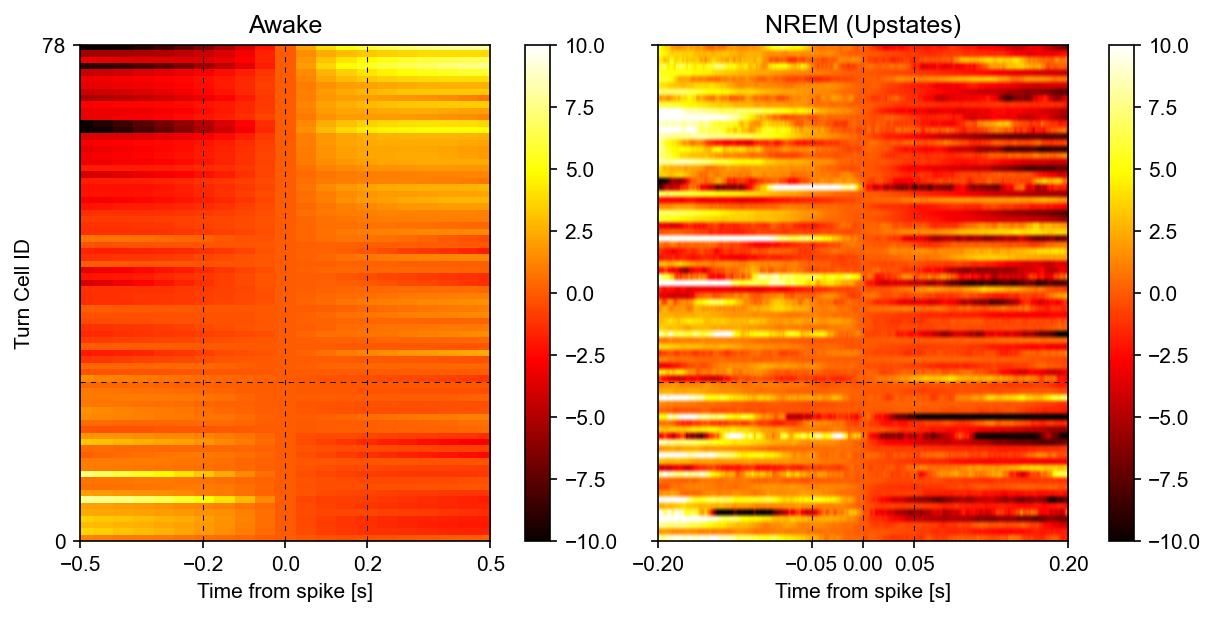

In [59]:
fig, axes = plot_heatmaps(
    mats=[sta_original.d, sta_nrem.d],
    times=[sta_original.t, sta_nrem.t],
    titles=["Awake", "NREM (Upstates)"],
    norm=TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10),
)

for ax in axes:
    ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.axhline(zero_cross, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.set_xlabel("Time from spike [s]")

axes[0].set_ylabel("Turn Cell ID")
axes[0].set_xlim([-0.5, 0.5])
axes[0].set_xticks([-0.5, -.2, 0, .2, 0.5])
axes[0].set_yticks([0, len(sta_original.columns)])
axes[0].axvline(0.2, color="k", linestyle=dashed_style, linewidth=0.5)
axes[0].axvline(-0.2, color="k", linestyle=dashed_style, linewidth=0.5)

axes[1].set_xlim((-.2, .2))
axes[1].set_xticks([-0.2, -.05, 0, .05, 0.2])
axes[1].axvline(0.05, color="k", linestyle=dashed_style, linewidth=0.5)
axes[1].axvline(-0.05, color="k", linestyle=dashed_style, linewidth=0.5)

plt.savefig(FIGURES_DIR / "sta_norm.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "sta_norm.png", format='png', bbox_inches='tight')

plt.show()

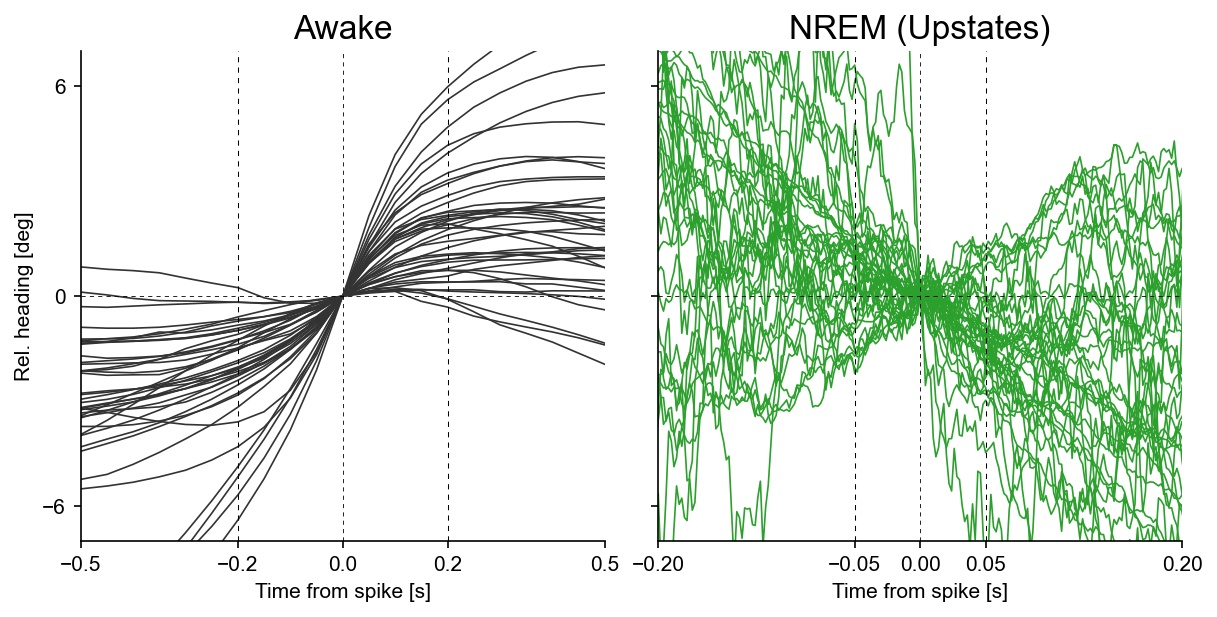

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
axes = axes.flatten()

mask = tsi>0.2

axes[0].plot(sta_original.index, sta_original[:, mask], color='0.2', linewidth=0.8)
axes[0].set_ylabel("Rel. heading [deg]")
axes[0].set_xlim([-0.5, 0.5])
axes[0].set_xticks([-0.5, -.2, 0, .2, 0.5])

axes[0].set_ylim([-7, 7])
axes[0].set_yticks([-6, 0, 6])

axes[0].axvline(x=0.2, color='k', linestyle=dashed_style, linewidth=0.5)
axes[0].axvline(x=-0.2, color='k', linestyle=dashed_style, linewidth=0.5)
axes[0].set_title(f"Awake", fontsize=16)

axes[1].plot(sta_nrem.index, sta_nrem[:, mask], color='tab:green', linewidth=0.8)
axes[1].set_xlim([-0.2, 0.2])
axes[1].set_xticks([-0.2, -.05, 0, .05, 0.2])
axes[1].axvline(x=0.05, color='k', linestyle=dashed_style, linewidth=0.5)
axes[1].axvline(x=-0.05, color='k', linestyle=dashed_style, linewidth=0.5)
axes[1].set_title(f"NREM (Upstates)", fontsize=16)

for ax in axes:
    ax.axhline(y=0, color='k', linestyle=dashed_style, linewidth=0.4)
    ax.axvline(x=0, color='k', linestyle=dashed_style, linewidth=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)    
    ax.set_xlabel("Time from spike [s]")

# fig.suptitle("TSI>0.2 Turn Cells", fontsize=18)
# plt.savefig(FIGURES_DIR / "sta" / "sta_cw_turns.png", format='png', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "sta" /"sta_cw_turns.svg", format='svg', bbox_inches='tight')
plt.show()

In [10]:
turn_amps_awake         = amplitude_at_threshold(sta_original, sta_original.t, 0.2)
turn_amps_nrem          = amplitude_at_threshold(sta_nrem, sta_nrem.t, 0.05)

In [14]:
turn_amps_awake

array([-0.9085999 , -3.10684084, -3.19565921, -3.41925056, -2.30516862,
       -2.36392148, -5.91035109, -1.84246983, -1.29313083, -1.2270389 ,
       -4.16867181, -1.15684987, -0.89472398, -2.09955572, -0.89235422,
       -3.19065354, -1.79668789,  0.23741507, -0.32422014, -0.2291272 ,
       -0.9532813 , -0.64963645, -0.73120083, -0.5764556 , -0.32281683,
       -0.93110642,  0.15221635, -0.01704263,  0.35655903,  2.0641141 ,
       -0.02697796,  0.73681285,  1.56442626,  1.14165905,  0.65219786,
        1.09811361,  0.48134814,  1.75895992,  1.40174503,  1.31291484,
        1.1863226 ,  0.77639002,  1.88163805,  0.35377745,  1.38601299,
        1.15813604,  0.31649356,  0.49787705,  2.02076226,  1.44785644,
        1.63532533,  2.14856321,  2.75864309,  3.74078174,  3.27636121,
        3.63487687,  2.43382257,  3.28565315,  3.04751496,  4.09349705,
        4.17958346,  4.23465118,  4.4549788 ,  5.24813309,  9.46890677,
        8.38757449,  4.04232736,  4.71232101,  5.02849186,  5.23

Text(0, 0.5, 'NREM amp. [deg]')

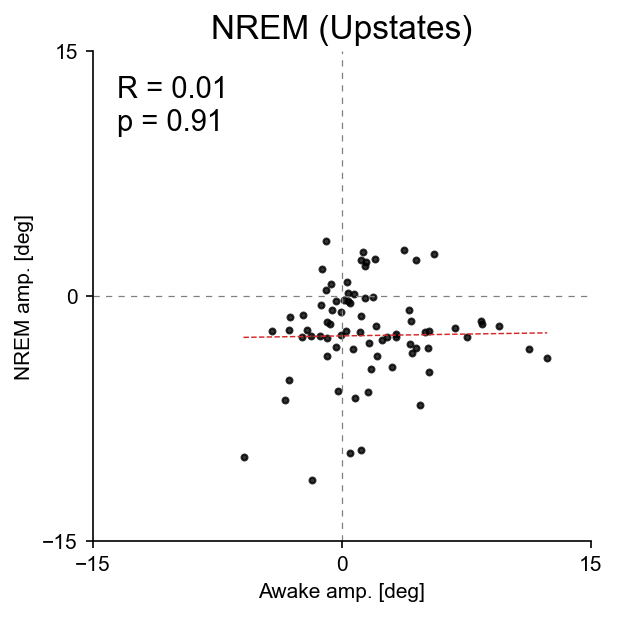

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

x, y = turn_amps_awake, turn_amps_nrem

fit = stats.linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = fit.intercept + fit.slope * x_fit

ax.scatter(x, y, s=8, c='k', alpha=0.8)
ax.plot(x_fit, y_fit, color='tab:red', linewidth=0.7, linestyle='--')
ax.axhline(0, color='0.5', linestyle=dashed_style, linewidth=0.6)
ax.axvline(0, color='0.5', linestyle=dashed_style, linewidth=0.6)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("Awake amp. [deg]")

label = (
    f'R = {fit.rvalue:.2f}\n'
    f'p = {fit.pvalue:.2g}\n'
)

ax.text(0.05, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontsize=14)
ax.set_xticks([-15, 0, 15])
ax.set_yticks([-15, 0, 15])
ax.set_xlim([-15, 15])
ax.set_ylim([-15, 15])

ax.set_title("NREM (Upstates)", fontsize=16)
ax.set_ylabel('NREM amp. [deg]')

# plt.savefig(FIGURES_DIR / "sta" / "turn_scatter.svg", format='svg', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "sta" / "turn_scatter.png", format='png', bbox_inches='tight')

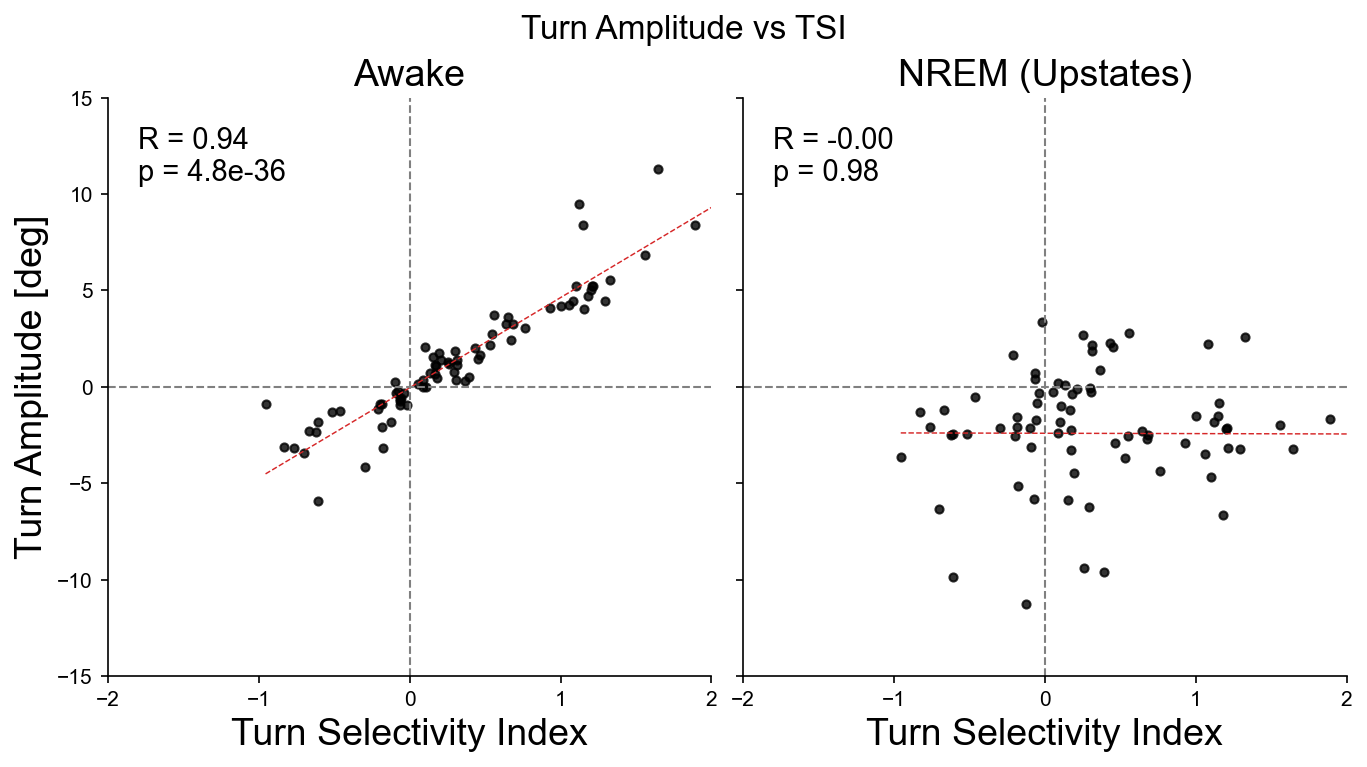

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharex=True, sharey=True, constrained_layout=True)

plot_scatter_with_regression(axes[0], tsi, turn_amps_awake, 'Awake', xlabel='Turn Selectivity Index', ylabel='Turn Amplitude [deg]')
plot_scatter_with_regression(axes[1], tsi, turn_amps_nrem, 'NREM (Upstates)', xlabel='Turn Selectivity Index', ylabel='')


for ax in axes:
    ax.set_xlim((-2, 2))
    ax.set_ylim((-15, 15))
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("Turn Amplitude vs TSI", fontsize=16)

plt.savefig(FIGURES_DIR / "sta" / "turn_scatter_tsi.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "sta" / "turn_scatter_tsi.png", format='png', bbox_inches='tight')